In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

### Generate 1000 random sequences background

In [2]:
def generate_random_dna_sequences(num_sequences=1000, seq_length=200, seed=42):
    random.seed(seed)
    bases = ['A', 'T', 'C', 'G']  
    sequences = [''.join(random.choices(bases, k=seq_length)) for _ in range(num_sequences)]

    df = pd.DataFrame({
        'seq_id': [f"seq_{i+1}" for i in range(num_sequences)],
        'random_seq': sequences
    })
    
    return df


### Load the DREAM-CNN model

/arc/project/st-cdeboer-1/sambina/miniconda3/envs/dream_rocky/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  seq_id                                         random_seq  predictions
0  seq_1  CATACCGATAACAACCACGAGCTAGTAAGCGCCGTCGCGCCAATAA...     9.910936
1  seq_2  GGGATATATGTGTTGGCCATGCCCACCGAGAACCAAGACCTCCGAC...    10.622983
2  seq_3  TATGGAACCTGGCAAAATGATCACTACAGGATAGCAAGTGCGCGGC...    10.663526
3  seq_4  ACTGCCTGAACTCTCTCTCTTAAACGAATCGCTAAAAACTGCCAGT...    12.125010
4  seq_5  TTCGTACTCCTTACCAGACCGTCGGTACCGGTCTCTCATGTCCGGG...    13.175313


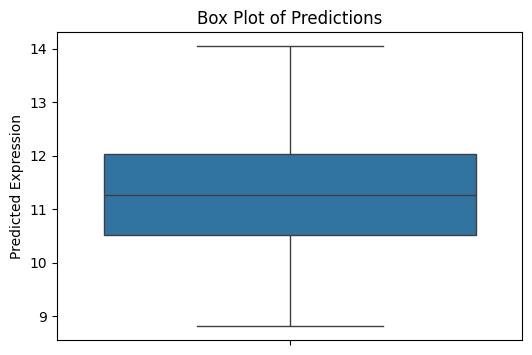

In [3]:
from tqdm import tqdm
import torch
import os
import sys

sys.path.append("/scratch/st-cdeboer-1/sambina/mpra/mpra_models/random-promoter-dream-challenge-2022")
from prixfixe.autosome import AutosomeDataProcessor, AutosomeFirstLayersBlock, AutosomeCoreBlock, AutosomeFinalLayersBlock, AutosomeTrainer, AutosomePredictor
from prixfixe.bhi import BHIFirstLayersBlock, BHICoreBlock
from prixfixe.unlockdna import UnlockDNACoreBlock
from prixfixe.prixfixe import PrixFixeNet

TRAIN_DATA_PATH = "/scratch/st-cdeboer-1/sambina/mpra/mpra_models/random-promoter-dream-challenge-2022/data/demo_train.txt" 
VALID_DATA_PATH = "/scratch/st-cdeboer-1/sambina/mpra/mpra_models/random-promoter-dream-challenge-2022/data/demo_val.txt" 
TRAIN_BATCH_SIZE = 512 
BATCH_PER_EPOCH = 10 
N_PROCS = 8
VALID_BATCH_SIZE = 4096
BATCH_PER_VALIDATION = 10
PLASMID_PATH = "/scratch/st-cdeboer-1/sambina/mpra/mpra_models/random-promoter-dream-challenge-2022/data/plasmid.json"
SEQ_SIZE = 150
NUM_EPOCHS = 5 
CUDA_DEVICE_ID = 0
lr = 0.005 


def predict(df):
    generator = torch.Generator()
    generator.manual_seed(2147483647)
    
    dataprocessor = AutosomeDataProcessor(
        path_to_training_data=TRAIN_DATA_PATH,
        path_to_validation_data=VALID_DATA_PATH,
        train_batch_size=TRAIN_BATCH_SIZE, 
        batch_per_epoch=BATCH_PER_EPOCH,
        train_workers=N_PROCS,
        valid_batch_size=VALID_BATCH_SIZE,
        valid_workers=N_PROCS,
        shuffle_train=True,
        shuffle_val=False,
        plasmid_path=PLASMID_PATH,
        seqsize=SEQ_SIZE,
        generator=generator
    )
    
    first = BHIFirstLayersBlock(
        in_channels = dataprocessor.data_channels(),
        out_channels = 320,
        seqsize = dataprocessor.data_seqsize(),
        kernel_sizes = [9, 15],
        pool_size = 1,
        dropout = 0.2
    )

    core = BHICoreBlock(
        in_channels = first.out_channels,
        out_channels = 320,
        seqsize = first.infer_outseqsize(),
        lstm_hidden_channels = 320,
        kernel_sizes = [9, 15],
        pool_size = 1,
        dropout1 = 0.2,
        dropout2 = 0.5
        )

    final = AutosomeFinalLayersBlock(in_channels=core.out_channels, 
                                 seqsize=core.infer_outseqsize())

    model = PrixFixeNet(
        first=first,
        core=core,
        final=final,
        generator=generator
    )

    predictor = AutosomePredictor(
        model=model, 
        # model_pth='/scratch/st-cdeboer-1/sambina/position_variant_effect/paper_analysis/figure_3/yeast_motifs/input/dream-cnn.pth',
        model_pth='/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/dream-rnn_retrained.pth',  
        device="cpu"
    )
    
    df['predictions'] = df['random_seq'].apply(lambda seq: predictor.predict(seq))
    print(df.head())
    return df

def plot(df):
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df['predictions'])
    plt.ylabel("Predicted Expression")
    plt.title("Box Plot of Predictions")
    plt.show()

    
        
def main():
    df = generate_random_dna_sequences()
    output_df = predict(df)
    output_df.to_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/predicted_thousand_random.csv")
    plot(output_df)
    
if __name__ == "__main__":
    main()

### Pick 500 sequences

In [4]:
import numpy as np
import pandas as pd

def select_percentile_sequences(df, num_sequences=500):
    lower_bound, upper_bound = df['predictions'].quantile([0.25, 0.75])
    filtered_df = df[(df['predictions'] >= lower_bound) & (df['predictions'] <= upper_bound)]
    selected_sequences = filtered_df.sample(n=min(num_sequences, len(filtered_df)), random_state=42)
    return selected_sequences[['seq_id', 'random_seq', 'predictions']]

df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/predicted_thousand_random.csv")
selected_df = select_percentile_sequences(df)
print(selected_df)
print(len(selected_df))


      seq_id                                         random_seq  predictions
728  seq_729  ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...    11.064396
144  seq_145  ACCGGATGGTCTAAGCCGTTAAGAAAAACAAAACTACGACCATTGA...    10.890359
751  seq_752  ACCTACCATCAAAATGGATAAGTACTCGTACCTTCAATACCACAGA...    10.596003
311  seq_312  GGGCGTTAGCCCCGGTGCAGAGTACGCTAATGAAGTCCTTTAAAGG...    10.933840
214  seq_215  TCATTCTAGGCGGCCGTCTGAACATAGACCTGACGGTCAGCACTTT...    11.752439
..       ...                                                ...          ...
218  seq_219  GTGATTAAGTTGCGGTTACCAATCAGTTCCAATCACAACATCTTTG...    11.826800
557  seq_558  CAAATGAACTTAGTTCTTGCATGGGAGGCCCCACGCAGGACTGGCC...    10.849731
702  seq_703  GGTGTTCACTGCGACATCAAATCCCATTCTAGGCCAGGAAGTATTG...    10.510008
875  seq_876  CCCTTGACATGGACTGCACTTCTTCAGACGGGACGCATCGGAAGTC...    11.445955
210  seq_211  ATGATCTTCCAAAAACCTCGCAAAATTTGTTCTTCGGACGTCCTTC...    11.551669

[500 rows x 3 columns]
500


### Place the 5 variants in the centre

In [5]:
motifs = {"Skn7": "GTCTGGCCC", "Mga1": "TTCT", "Ume6": "AGCCGCC", "Mot3": "GCAGGCACG", "Azf1": "TAAAAGAAA", "polyA": "AAAAA", "Abf1": "CCGTAAAAAGTGAT", "Rap1": "CACCCCATACA", "Hap1": "CGGAGATA"}

In [6]:
mutated_motifs = {key + "_mut": "N" * len(value) for key, value in motifs.items()}
mutated_motifs_list = {**motifs, **mutated_motifs}

print(mutated_motifs_list)

{'Skn7': 'GTCTGGCCC', 'Mga1': 'TTCT', 'Ume6': 'AGCCGCC', 'Mot3': 'GCAGGCACG', 'Azf1': 'TAAAAGAAA', 'polyA': 'AAAAA', 'Abf1': 'CCGTAAAAAGTGAT', 'Rap1': 'CACCCCATACA', 'Hap1': 'CGGAGATA', 'Skn7_mut': 'NNNNNNNNN', 'Mga1_mut': 'NNNN', 'Ume6_mut': 'NNNNNNN', 'Mot3_mut': 'NNNNNNNNN', 'Azf1_mut': 'NNNNNNNNN', 'polyA_mut': 'NNNNN', 'Abf1_mut': 'NNNNNNNNNNNNNN', 'Rap1_mut': 'NNNNNNNNNNN', 'Hap1_mut': 'NNNNNNNN'}


In [7]:
def place_motifs_with_offsets(df, motifs, offsets=[0]):
    new_data = []

    for _, row in df.iterrows():
        sequence = row["random_seq"]
        seq_id = row["seq_id"]
        seq_length = len(sequence)
        center_pos = seq_length // 2  

        for motif_name, motif_seq in motifs.items():
            motif_length = len(motif_seq)

            for offset in offsets:
                start_pos = center_pos - (motif_length // 2)
                
                if start_pos < 0 or start_pos + motif_length > seq_length:
                    continue  

                new_sequence = sequence[:start_pos] + motif_seq + sequence[start_pos + motif_length:]
                new_data.append([seq_id, motif_name, new_sequence, start_pos, offset])

    new_df = pd.DataFrame(new_data, columns=["seq_id", "motif_name", "seq_200", "start_pos", "offset"])
    return new_df

In [8]:
print(selected_df)
dataframe = place_motifs_with_offsets(selected_df, mutated_motifs_list)
dataframe

      seq_id                                         random_seq  predictions
728  seq_729  ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...    11.064396
144  seq_145  ACCGGATGGTCTAAGCCGTTAAGAAAAACAAAACTACGACCATTGA...    10.890359
751  seq_752  ACCTACCATCAAAATGGATAAGTACTCGTACCTTCAATACCACAGA...    10.596003
311  seq_312  GGGCGTTAGCCCCGGTGCAGAGTACGCTAATGAAGTCCTTTAAAGG...    10.933840
214  seq_215  TCATTCTAGGCGGCCGTCTGAACATAGACCTGACGGTCAGCACTTT...    11.752439
..       ...                                                ...          ...
218  seq_219  GTGATTAAGTTGCGGTTACCAATCAGTTCCAATCACAACATCTTTG...    11.826800
557  seq_558  CAAATGAACTTAGTTCTTGCATGGGAGGCCCCACGCAGGACTGGCC...    10.849731
702  seq_703  GGTGTTCACTGCGACATCAAATCCCATTCTAGGCCAGGAAGTATTG...    10.510008
875  seq_876  CCCTTGACATGGACTGCACTTCTTCAGACGGGACGCATCGGAAGTC...    11.445955
210  seq_211  ATGATCTTCCAAAAACCTCGCAAAATTTGTTCTTCGGACGTCCTTC...    11.551669

[500 rows x 3 columns]


,seq_id,motif_name,seq_200,start_pos,offset
0,seq_729,Skn7,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,96,0
1,seq_729,Mga1,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,98,0
2,seq_729,Ume6,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,97,0
3,seq_729,Mot3,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,96,0
4,seq_729,Azf1,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,96,0
...,...,...,...,...,...
8995,seq_211,Azf1_mut,ATGATCTTCCAAAAACCTCGCAAAATTTGTTCTTCGGACGTCCTTC...,96,0
8996,seq_211,polyA_mut,ATGATCTTCCAAAAACCTCGCAAAATTTGTTCTTCGGACGTCCTTC...,98,0
8997,seq_211,Abf1_mut,ATGATCTTCCAAAAACCTCGCAAAATTTGTTCTTCGGACGTCCTTC...,93,0
8998,seq_211,Rap1_mut,ATGATCTTCCAAAAACCTCGCAAAATTTGTTCTTCGGACGTCCTTC...,95,0


In [9]:
def find_differences(df1, df2, offset):
    """
    Compare seq_ref and seq_alt in two DataFrames and find differing positions.

    Parameters:
        df1 (pd.DataFrame): DataFrame containing 'seq_ref'.
        df2 (pd.DataFrame): DataFrame containing 'seq_alt'.

    Returns:
        pd.DataFrame: Updated df1 with a new 'diff_index' column.
    """
    if len(df1) != len(df2):
        raise ValueError("DataFrames must have the same number of rows!")

    diff_indices = []

    for (_, row1), (_, row2) in zip(df1.iterrows(), df2.iterrows()):
        seq_ref = row1[f"seq_ref_{offset}"]
        seq_alt = row2[f"seq_alt_{offset}"]

        if len(seq_ref) != len(seq_alt):
            print("Length not equal")
            
            diffs = pd.NA  
        else:
            diffs = [i for i, (ref_char, alt_char) in enumerate(zip(seq_ref, seq_alt)) if ref_char != alt_char]
            diffs = diffs if diffs else pd.NA  

        diff_indices.append(diffs)

    df1 = df1.copy()
    df1["diff_index"] = diff_indices

    return df1


### Create the 80 bp sequences with the offsets

In [10]:
import pandas as pd

BLUE = "\033[1;34m"  
RED = "\033[1;31m"   
RESET = "\033[0m"   

def color_text(sequence, motif_start, motif_length, window_start, window_end):
    """
    Colors the sequence:
    - Blue: The extracted 80 bp window.
    - Red: The motif inside the extracted window.
    """
    colored_sequence = ""

    for i, base in enumerate(sequence):
        if window_start <= i < window_end:  
            if motif_start <= i < motif_start + motif_length:  
                colored_sequence += f"{RED}{base}{RESET}"  # Red for motif
            else:
                colored_sequence += f"{BLUE}{base}{RESET}"  # Blue for 80 bp window
        else:
            colored_sequence += base  # Default color (no highlight)

    return colored_sequence

def extract_80bp_windows_with_offsets(df, motif_col="motif_name", offsets = list(range(-30, 31, 1))):
    """
    Extracts 80 bp windows from sequences, centering the motif at various offsets.

    Parameters:
    - df: DataFrame containing sequences and motifs.
    - allele: "ref" or "alt" to select sequence column.
    - motif_col: Column with motif names.
    - offsets: List of offsets to shift the motif.

    Returns:
    - DataFrame with extracted 200 bp windows for each offset.
    """
    seq_col = f"seq_200"

    for offset in offsets:
        extracted_windows = []

        for _, row in df.iterrows():
            sequence = row[seq_col]  # Full 200 bp sequence
            motif_name = row[motif_col]

            # Get motif sequence
            if motif_name in mutated_motifs_list:
                motif = mutated_motifs_list[motif_name]
            else:
                raise ValueError(f"Motif '{motif_name}' not found in the motifs dictionary.")

            motif_length = len(motif)
            seq_length = len(sequence)  # Should be 200 bp
            center = seq_length // 2  # 100th base as center

            # Adjust motif position using offset
            motif_start = center - (motif_length // 2) + offset  

            # Extract 80 bp window centered on the motif **with offset taken into account**
            window_start = motif_start - (40 - motif_length // 2)
            window_end = window_start + 80
            extracted_window = sequence[window_start:window_end]
            extracted_windows.append(extracted_window)

            # Print colored sequence for verification
            # print(f"\nOffset {offset}:")
            # print(f"Extracted 80 bp window:\n{sequence[window_start:window_end]}")
            # print(color_text(sequence, motif_start, motif_length, window_start, window_end))
            # print("-" * 200)

        # Add new column for each offset
        df[f"seq_{offset}"] = extracted_windows

    return df

# Run on reference DataFrame
df_80bp = extract_80bp_windows_with_offsets(dataframe)
df_80bp.head(5)


,seq_id,motif_name,seq_200,start_pos,offset,seq_-30,seq_-29,seq_-28,seq_-27,seq_-26,...,seq_21,seq_22,seq_23,seq_24,seq_25,seq_26,seq_27,seq_28,seq_29,seq_30
0,seq_729,Skn7,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,96,0,TCAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACC...,CAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCC...,AACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCG...,ACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGG...,CGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGGT...,...,AGTTATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGT...,GTTATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTG...,TTATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGA...,TATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAG...,ATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGG...,TCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGGT...,CGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGGTC...,GGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGGTCT...,GTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGGTCTA...,TTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGGTCTAG...
1,seq_729,Mga1,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,98,0,TCAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACC...,CAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCC...,AACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCG...,ACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGG...,CGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGGT...,...,AGTTATCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGT...,GTTATCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTG...,TTATCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGA...,TATCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAG...,ATCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGG...,TCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGGT...,CGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGGTC...,GGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGGTCT...,GTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGGTCTA...,TTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGGTCTAG...
2,seq_729,Ume6,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,97,0,TCAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACC...,CAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCC...,AACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCG...,ACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGG...,CGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGGT...,...,AGTTATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGT...,GTTATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTG...,TTATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGA...,TATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAG...,ATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGG...,TCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGGT...,CGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGGTC...,GGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGGTCT...,GTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGGTCTA...,TTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGGTCTAG...
3,seq_729,Mot3,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,96,0,TCAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACC...,CAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCC...,AACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCG...,ACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGG...,CGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGGT...,...,AGTTATCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGT...,GTTATCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTG...,TTATCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGA...,TATCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAG...,ATCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGG...,TCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGGT...,CGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGGTC...,GGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGGTCT...,GTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGGTCTA...,TTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGGTCTAG...
4,seq_729,Azf1,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,96,0,TCAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACC...,CAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCC...,AACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCG...,ACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGG...,CGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGGT...,...,AGTTATCGGTTTCGCTAAAAGAAAGTGTCGCGAGTTGTTTGCGTGT...,GTTATCGGTTTCGCTAAAAGAAAGTGTCGCGAGTTGTTTGCGTGTG...,TTATCGGTTTCGCTAAAAGAAAGTGTCGCGAGTTGTTTGCGTGTGA...,TATCGGTTTCGCTAAAAGAAAGTGTCGCGAGTTGTTTGCGTGTGAG...,ATCGGTTTCGCTAAAAGAAAGT

In [11]:
df_80bp

,seq_id,motif_name,seq_200,start_pos,offset,seq_-30,seq_-29,seq_-28,seq_-27,seq_-26,...,seq_21,seq_22,seq_23,seq_24,seq_25,seq_26,seq_27,seq_28,seq_29,seq_30
0,seq_729,Skn7,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,96,0,TCAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACC...,CAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCC...,AACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCG...,ACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGG...,CGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGGT...,...,AGTTATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGT...,GTTATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTG...,TTATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGA...,TATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAG...,ATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGG...,TCGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGGT...,CGGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGGTC...,GGTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGGTCT...,GTTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGGTCTA...,TTTCGCGTCTGGCCCGTGTCGCGAGTTGTTTGCGTGTGAGGTCTAG...
1,seq_729,Mga1,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,98,0,TCAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACC...,CAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCC...,AACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCG...,ACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGG...,CGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGGT...,...,AGTTATCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGT...,GTTATCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTG...,TTATCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGA...,TATCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAG...,ATCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGG...,TCGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGGT...,CGGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGGTC...,GGTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGGTCT...,GTTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGGTCTA...,TTTCGCCATTCTTATGTGTCGCGAGTTGTTTGCGTGTGAGGTCTAG...
2,seq_729,Ume6,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,97,0,TCAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACC...,CAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCC...,AACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCG...,ACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGG...,CGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGGT...,...,AGTTATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGT...,GTTATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTG...,TTATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGA...,TATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAG...,ATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGG...,TCGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGGT...,CGGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGGTC...,GGTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGGTCT...,GTTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGGTCTA...,TTTCGCCAGCCGCCTGTGTCGCGAGTTGTTTGCGTGTGAGGTCTAG...
3,seq_729,Mot3,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,96,0,TCAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACC...,CAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCC...,AACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCG...,ACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGG...,CGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGGT...,...,AGTTATCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGT...,GTTATCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTG...,TTATCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGA...,TATCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAG...,ATCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGG...,TCGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGGT...,CGGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGGTC...,GGTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGGTCT...,GTTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGGTCTA...,TTTCGCGCAGGCACGGTGTCGCGAGTTGTTTGCGTGTGAGGTCTAG...
4,seq_729,Azf1,ACGGCTAGCGGGGTCGTTAAAGGTCGTTGATCAACGCGTATCGCCC...,96,0,TCAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACC...,CAACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCC...,AACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCG...,ACGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGG...,CGCGTATCGCCCCTCTGTCTGCTAGGAGTCAAACATCGCACCCGGT...,...,AGTTATCGGTTTCGCTAAAAGAAAGTGTCGCGAGTTGTTTGCGTGT...,GTTATCGGTTTCGCTAAAAGAAAGTGTCGCGAGTTGTTTGCGTGTG...,TTATCGGTTTCGCTAAAAGAAAGTGTCGCGAGTTGTTTGCGTGTGA...,TATCGGTTTCGCTAAAAGAAAGTGTCGCGAGTTGTTTGCGTGTGAG...,ATCGGTTTCGCTAAAAGAAAGT

In [12]:
def validate_sequence_lengths(df, expected_length, offsets = list(range(-30, 31, 1))):
    """
    Checks if sequences in the DataFrame have the expected length (80 bp) for given offsets.

    Parameters:
    - df: DataFrame containing sequences.
    - allele: "ref" or "alt" to check the correct sequence column.
    - offsets: List of offsets to check.
    - expected_length: Expected length of sequences (default: 80 bp).

    Raises:
    - ValueError if any sequence length is not 80 bp.
    """
    for offset in offsets:
        column_name = f"seq_{offset}"  # Column name format
        
        if column_name not in df.columns:
            raise ValueError(f"Column '{column_name}' not found in DataFrame.")

        # Check sequence lengths
        for i, seq in enumerate(df[column_name]):
            if len(seq) != expected_length:
                raise ValueError(f"Error in row {i}, column '{column_name}': Expected {expected_length} bp, got {len(seq)} bp")

    print("✅ All sequences have the correct length.")

# Run validation on the DataFrame
validate_sequence_lengths(df_80bp, 80)


✅ All sequences have the correct length.


In [13]:
# Define the sequences to add
left_adapter = "TGCATTTTTTTCACATC"
right_adapter = "GGTTACGGCTGTT"

for col in df_80bp.columns:
    if col.startswith('seq_'):  
        if col != "seq_id":
            df_80bp[col] = df_80bp[col].apply(lambda seq: left_adapter + seq + right_adapter)


In [14]:
df_80bp

,seq_id,motif_name,seq_200,start_pos,offset,seq_-30,seq_-29,seq_-28,seq_-27,seq_-26,...,seq_21,seq_22,seq_23,seq_24,seq_25,seq_26,seq_27,seq_28,seq_29,seq_30
0,seq_729,Skn7,TGCATTTTTTTCACATCACGGCTAGCGGGGTCGTTAAAGGTCGTTG...,96,0,TGCATTTTTTTCACATCTCAACGCGTATCGCCCCTCTGTCTGCTAG...,TGCATTTTTTTCACATCCAACGCGTATCGCCCCTCTGTCTGCTAGG...,TGCATTTTTTTCACATCAACGCGTATCGCCCCTCTGTCTGCTAGGA...,TGCATTTTTTTCACATCACGCGTATCGCCCCTCTGTCTGCTAGGAG...,TGCATTTTTTTCACATCCGCGTATCGCCCCTCTGTCTGCTAGGAGT...,...,TGCATTTTTTTCACATCAGTTATCGGTTTCGCGTCTGGCCCGTGTC...,TGCATTTTTTTCACATCGTTATCGGTTTCGCGTCTGGCCCGTGTCG...,TGCATTTTTTTCACATCTTATCGGTTTCGCGTCTGGCCCGTGTCGC...,TGCATTTTTTTCACATCTATCGGTTTCGCGTCTGGCCCGTGTCGCG...,TGCATTTTTTTCACATCATCGGTTTCGCGTCTGGCCCGTGTCGCGA...,TGCATTTTTTTCACATCTCGGTTTCGCGTCTGGCCCGTGTCGCGAG...,TGCATTTTTTTCACATCCGGTTTCGCGTCTGGCCCGTGTCGCGAGT...,TGCATTTTTTTCACATCGGTTTCGCGTCTGGCCCGTGTCGCGAGTT...,TGCATTTTTTTCACATCGTTTCGCGTCTGGCCCGTGTCGCGAGTTG...,TGCATTTTTTTCACATCTTTCGCGTCTGGCCCGTGTCGCGAGTTGT...
1,seq_729,Mga1,TGCATTTTTTTCACATCACGGCTAGCGGGGTCGTTAAAGGTCGTTG...,98,0,TGCATTTTTTTCACATCTCAACGCGTATCGCCCCTCTGTCTGCTAG...,TGCATTTTTTTCACATCCAACGCGTATCGCCCCTCTGTCTGCTAGG...,TGCATTTTTTTCACATCAACGCGTATCGCCCCTCTGTCTGCTAGGA...,TGCATTTTTTTCACATCACGCGTATCGCCCCTCTGTCTGCTAGGAG...,TGCATTTTTTTCACATCCGCGTATCGCCCCTCTGTCTGCTAGGAGT...,...,TGCATTTTTTTCACATCAGTTATCGGTTTCGCCATTCTTATGTGTC...,TGCATTTTTTTCACATCGTTATCGGTTTCGCCATTCTTATGTGTCG...,TGCATTTTTTTCACATCTTATCGGTTTCGCCATTCTTATGTGTCGC...,TGCATTTTTTTCACATCTATCGGTTTCGCCATTCTTATGTGTCGCG...,TGCATTTTTTTCACATCATCGGTTTCGCCATTCTTATGTGTCGCGA...,TGCATTTTTTTCACATCTCGGTTTCGCCATTCTTATGTGTCGCGAG...,TGCATTTTTTTCACATCCGGTTTCGCCATTCTTATGTGTCGCGAGT...,TGCATTTTTTTCACATCGGTTTCGCCATTCTTATGTGTCGCGAGTT...,TGCATTTTTTTCACATCGTTTCGCCATTCTTATGTGTCGCGAGTTG...,TGCATTTTTTTCACATCTTTCGCCATTCTTATGTGTCGCGAGTTGT...
2,seq_729,Ume6,TGCATTTTTTTCACATCACGGCTAGCGGGGTCGTTAAAGGTCGTTG...,97,0,TGCATTTTTTTCACATCTCAACGCGTATCGCCCCTCTGTCTGCTAG...,TGCATTTTTTTCACATCCAACGCGTATCGCCCCTCTGTCTGCTAGG...,TGCATTTTTTTCACATCAACGCGTATCGCCCCTCTGTCTGCTAGGA...,TGCATTTTTTTCACATCACGCGTATCGCCCCTCTGTCTGCTAGGAG...,TGCATTTTTTTCACATCCGCGTATCGCCCCTCTGTCTGCTAGGAGT...,...,TGCATTTTTTTCACATCAGTTATCGGTTTCGCCAGCCGCCTGTGTC...,TGCATTTTTTTCACATCGTTATCGGTTTCGCCAGCCGCCTGTGTCG...,TGCATTTTTTTCACATCTTATCGGTTTCGCCAGCCGCCTGTGTCGC...,TGCATTTTTTTCACATCTATCGGTTTCGCCAGCCGCCTGTGTCGCG...,TGCATTTTTTTCACATCATCGGTTTCGCCAGCCGCCTGTGTCGCGA...,TGCATTTTTTTCACATCTCGGTTTCGCCAGCCGCCTGTGTCGCGAG...,TGCATTTTTTTCACATCCGGTTTCGCCAGCCGCCTGTGTCGCGAGT...,TGCATTTTTTTCACATCGGTTTCGCCAGCCGCCTGTGTCGCGAGTT...,TGCATTTTTTTCACATCGTTTCGCCAGCCGCCTGTGTCGCGAGTTG...,TGCATTTTTTTCACATCTTTCGCCAGCCGCCTGTGTCGCGAGTTGT...
3,seq_729,Mot3,TGCATTTTTTTCACATCACGGCTAGCGGGGTCGTTAAAGGTCGTTG...,96,0,TGCATTTTTTTCACATCTCAACGCGTATCGCCCCTCTGTCTGCTAG...,TGCATTTTTTTCACATCCAACGCGTATCGCCCCTCTGTCTGCTAGG...,TGCATTTTTTTCACATCAACGCGTATCGCCCCTCTGTCTGCTAGGA...,TGCATTTTTTTCACATCACGCGTATCGCCCCTCTGTCTGCTAGGAG...,TGCATTTTTTTCACATCCGCGTATCGCCCCTCTGTCTGCTAGGAGT...,...,TGCATTTTTTTCACATCAGTTATCGGTTTCGCGCAGGCACGGTGTC...,TGCATTTTTTTCACATCGTTATCGGTTTCGCGCAGGCACGGTGTCG...,TGCATTTTTTTCACATCTTATCGGTTTCGCGCAGGCACGGTGTCGC...,TGCATTTTTTTCACATCTATCGGTTTCGCGCAGGCACGGTGTCGCG...,TGCATTTTTTTCACATCATCGGTTTCGCGCAGGCACGGTGTCGCGA...,TGCATTTTTTTCACATCTCGGTTTCGCGCAGGCACGGTGTCGCGAG...,TGCATTTTTTTCACATCCGGTTTCGCGCAGGCACGGTGTCGCGAGT...,TGCATTTTTTTCACATCGGTTTCGCGCAGGCACGGTGTCGCGAGTT...,TGCATTTTTTTCACATCGTTTCGCGCAGGCACGGTGTCGCGAGTTG...,TGCATTTTTTTCACATCTTTCGCGCAGGCACGGTGTCGCGAGTTGT...
4,seq_729,Azf1,TGCATTTTTTTCACATCACGGCTAGCGGGGTCGTTAAAGGTCGTTG...,96,0,TGCATTTTTTTCACATCTCAACGCGTATCGCCCCTCTGTCTGCTAG...,TGCATTTTTTTCACATCCAACGCGTATCGCCCCTCTGTCTGCTAGG...,TGCATTTTTTTCACATCAACGCGTATCGCCCCTCTGTCTGCTAGGA...,TGCATTTTTTTCACATCACGCGTATCGCCCCTCTGTCTGCTAGGAG...,TGCATTTTTTTCACATCCGCGTATCGCCCCTCTGTCTGCTAGGAGT...,...,TGCATTTTTTTCACATCAGTTATCGGTTTCGCTAAAAGAAAGTGTC...,TGCATTTTTTTCACATCGTTATCGGTTTCGCTAAAAGAAAGTGTCG...,TGCATTTTTTTCACATCTTATCGGTTTCGCTAAAAGAAAGTGTCGC...,TGCATTTTTTTCACATCTATCGGTTTCGCTAAAAGAAAGTGTCGCG...,TGCATTTTTTTCACATCATCGG

In [15]:
df_80bp.to_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/all_yeast_variants_full_knockout.csv")

### Create Reverse Complement of the sequences (only middle section)

In [ ]:
from Bio.Seq import Seq

# Define adapters
left_adapter = "TGCATTTTTTTCACATC"
right_adapter = "GGTTACGGCTGTT"

# Function to process sequence
def process_sequence(seq):
    # Remove adapters if they are present
    if seq.startswith(left_adapter):
        seq = seq[len(left_adapter):]  # Remove left adapter
    if seq.endswith(right_adapter):
        seq = seq[:-len(right_adapter)]  # Remove right adapter
    
    # Reverse complement the sequence
    rev_comp_seq = str(Seq(seq).reverse_complement())

    # Add adapters back
    return left_adapter + rev_comp_seq + right_adapter

# Create a new DataFrame where seq_ columns are modified
df_80bp_rc = df_80bp.copy()  # Copy original DataFrame

# Apply processing only to columns starting with "seq_"
for col in df_80bp_rc.columns:
    if col.startswith("seq_"):
        if col!="seq_id":
            df_80bp_rc[col] = df_80bp_rc[col].apply(process_sequence)


df_80bp_rc
df_80bp_rc.to_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/all_yeast_variants_full_knockout_rc.csv")
